# AI Based IPC Section Classifier

## Project Objective

This notebook builds an Explainable Machine Learning model to classify 
crime descriptions into IPC sections using:

- TF-IDF Feature Engineering
- Support Vector Machine (SVM)
- Probability Calibration
- Feature Contribution Analysis
- Rule-Based Legal Reasoning

The model aims to provide both prediction accuracy and interpretability.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from tqdm import tqdm

tqdm.pandas()

In [2]:
df = pd.read_csv("final_crime_ipc_dataset.csv")

In [3]:
df

,crime_description,law_section
0,"smt. brahmadevi vs state of u.p. on may, . as ...",IPC 302
1,"raju rajkumar vs state on february, reportable...",IPC 302
2,the state of madhya pradesh vs sitaram surety ...,IPC 302
3,". sri vivek kumar singh sri mayank yadav, advo...",IPC 302
4,in jail with criminal no. of lal chand mia abd...,IPC 302
...,...,...
1255,dr. ashok kumar agrawal vs state of u.p. other...,IPC 506
1256,"on or before , the accused had caused disappea...",IPC 506
1257,six or seven months prior to the date of compl...,IPC 506
1258,"indira vs danaseelan mudaliyar on october, . t...",IPC 506


In [4]:
df = df.dropna(subset=["crime_description"])

In [5]:
print("Total Samples:", len(df))

Total Samples: 1260


In [6]:
print("Available IPC Sections:", df["law_section"].unique())

Available IPC Sections: ['IPC 302' 'IPC 323' 'IPC 354' 'IPC 379' 'IPC 392' 'IPC 420' 'IPC 506']


Select 4 IPC Sections

In [7]:
selected_ipcs = ['IPC 302', 'IPC 379', 'IPC 420', 'IPC 506']
df = df[df["law_section"].isin(selected_ipcs)]

df["law_section"].value_counts()

law_section
IPC 302    180
IPC 379    180
IPC 420    180
IPC 506    180
Name: count, dtype: int64

Preprocessing

In [8]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["processed"] = df["crime_description"].progress_apply(preprocess)

100%|██████████████████████████████████████████████████████████████████████████████| 720/720 [00:00<00:00, 4842.58it/s]


In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["law_section"],
    random_state=42
)

print("Train Size:", len(train_df))
print("Test Size:", len(test_df))

Train Size: 576
Test Size: 144


In [10]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df["law_section"])
y_test = encoder.transform(test_df["law_section"])

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    stop_words="english",
    max_features=30000,
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

svm = LinearSVC(
    C=1.2,
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

pipeline = Pipeline([
    ("tfidf", tfidf),
    ("svm", svm)
])

# Cross Validation

In [11]:
cv_scores = cross_val_score(pipeline, train_df["processed"], y_train, cv=5)
print("Cross Validation Accuracy:", round(cv_scores.mean(),4))

Cross Validation Accuracy: 0.8125


In [12]:
pipeline.fit(train_df["processed"], y_train)

,steps,"[('tfidf', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [13]:
calibrated_model = CalibratedClassifierCV(pipeline, cv=3)
calibrated_model.fit(train_df["processed"], y_train)

,estimator,Pipeline(step...m_state=42))])
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None


# Model Evaluation

In [14]:
test_preds = calibrated_model.predict(test_df["processed"])
decoded_preds = encoder.inverse_transform(test_preds)

accuracy = accuracy_score(test_df["law_section"], decoded_preds)

print("Test Accuracy:", round(accuracy,4))
print("\nClassification Report:\n")
print(classification_report(test_df["law_section"], decoded_preds))

Test Accuracy: 0.7639

Classification Report:

              precision    recall  f1-score   support

     IPC 302       0.74      0.86      0.79        36
     IPC 379       0.78      0.69      0.74        36
     IPC 420       0.91      0.81      0.85        36
     IPC 506       0.66      0.69      0.68        36

    accuracy                           0.76       144
   macro avg       0.77      0.76      0.76       144
weighted avg       0.77      0.76      0.76       144



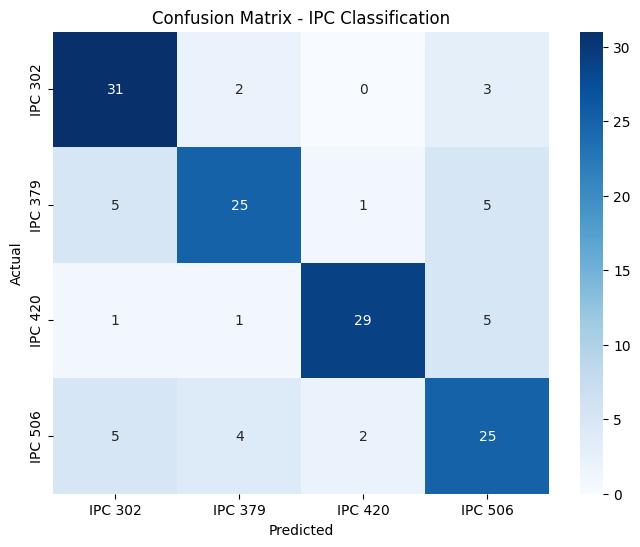

In [15]:
cm = confusion_matrix(test_df["law_section"], decoded_preds, labels=selected_ipcs)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=selected_ipcs,
            yticklabels=selected_ipcs)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - IPC Classification")
plt.show()

In [16]:
rules = {
    'IPC 302': ['knife', 'gun', 'stab', 'shoot', 'died', 'death', 'killed'],
    'IPC 379': ['stole', 'steal', 'theft', 'wallet', 'mobile', 'snatch'],
    'IPC 420': ['cheat', 'fraud', 'fake', 'investment', 'scam'],
    'IPC 506': ['threaten', 'kill', 'warn', 'intimidate', 'harm']
}

In [17]:
def explain_prediction(text):

    processed = preprocess(text)
    pred_idx = calibrated_model.predict([processed])[0]
    predicted_ipc = encoder.inverse_transform([pred_idx])[0]

    probs = calibrated_model.predict_proba([processed])[0]
    confidence = max(probs) * 100

    calibrated = calibrated_model.calibrated_classifiers_[0]
    pipe = calibrated.estimator
    vectorizer = pipe.named_steps["tfidf"]
    svm_model = pipe.named_steps["svm"]

    text_features = vectorizer.transform([processed])
    coef = svm_model.coef_[pred_idx]

    contributions = text_features.toarray()[0] * coef
    feature_names = vectorizer.get_feature_names_out()

    top_indices = np.argsort(contributions)[-5:][::-1]

    top_words = []
    for idx in top_indices:
        if contributions[idx] > 0:
            top_words.append((feature_names[idx], round(contributions[idx],3)))

    matched_rules = [word for word in rules[predicted_ipc] if word in text.lower()]

    print("="*60)
    print("TEXT:", text)
    print("="*60)
    print("\nPredicted IPC:", predicted_ipc)
    print("Confidence:", round(confidence,2), "%")

    print("\nTop Contributing Words:")
    for word, score in top_words:
        print(" ", word, "(", score, ")")

    print("\nLegal Rule Matches:")
    if matched_rules:
        for m in matched_rules:
            print(" ", m)
    else:
        print("  None")

# Sample Test Cases

In [18]:
sample_cases = [
    "The accused stabbed the victim multiple times with a knife and he died on the spot.",
    "The suspect stole a mobile phone from the victim's pocket without his knowledge.",
    "The accused cheated investors by promising fake investment returns and took money.",
    "The man threatened to kill the shopkeeper if he did not pay money immediately.",
    "The robber intimidated the victim and warned him of serious harm if he complained."
]

for case in sample_cases:
    explain_prediction(case)

TEXT: The accused stabbed the victim multiple times with a knife and he died on the spot.

Predicted IPC: IPC 302
Confidence: 50.74 %

Top Contributing Words:
  knife ( 0.171 )
  stabbed ( 0.113 )
  died spot ( 0.084 )
  times ( 0.06 )
  died ( 0.056 )

Legal Rule Matches:
  knife
  stab
  died
TEXT: The suspect stole a mobile phone from the victim's pocket without his knowledge.

Predicted IPC: IPC 379
Confidence: 78.41 %

Top Contributing Words:
  mobile ( 0.254 )
  phone ( 0.222 )
  mobile phone ( 0.216 )
  pocket ( 0.197 )

Legal Rule Matches:
  stole
  mobile
TEXT: The accused cheated investors by promising fake investment returns and took money.

Predicted IPC: IPC 420
Confidence: 55.43 %

Top Contributing Words:
  money ( 0.065 )
  fake ( 0.031 )
  cheated ( 0.008 )

Legal Rule Matches:
  cheat
  fake
  investment
TEXT: The man threatened to kill the shopkeeper if he did not pay money immediately.

Predicted IPC: IPC 506
Confidence: 80.43 %

Top Contributing Words:
  threatened 

# Manual Testing 

In [ ]:
# User Input Testing Cell

while True:
    user_text = input("\nEnter crime description (or type 'exit' to stop): ")
    
    if user_text.lower() == "exit":
        print("Exiting...")
        break
    
    explain_prediction(user_text)